In [2]:
import sys
from pathlib import Path

# Add the project root to sys.path so we can import the local package.
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.pairs.data import download_prices, compute_log_returns
from src.pairs.universe import UNIVERSE

# Standard plotting settings.
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["figure.dpi"] = 100

In [3]:
prices = download_prices()
returns = compute_log_returns(prices)

print(f"Loaded prices: {prices.shape[0]} days × {prices.shape[1]} tickers")
print(f"Date range: {prices.index.min().date()} to {prices.index.max().date()}")
prices.head()

Loaded prices: 1258 days × 31 tickers
Date range: 2020-01-02 to 2024-12-31


,AAPL,MSFT,GOOGL,META,AMZN,NVDA,AMD,INTC,TSM,AVGO,...,CVX,COP,SLB,T,VZ,DIS,NFLX,BA,CAT,GE
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,72.333878,151.829575,67.873024,208.146561,94.900497,5.970754,49.099998,53.666466,53.628571,27.677496,...,91.182587,51.773109,34.669903,18.787169,41.978821,144.790268,32.980999,331.348572,132.312897,57.747486
2020-01-03,71.630623,149.939011,67.517967,207.045197,93.748497,5.875187,48.599998,53.013718,51.860001,26.973518,...,90.867188,51.962944,35.006504,18.883856,41.531868,143.129379,32.590000,330.791901,130.475800,57.941116
2020-01-06,72.201424,150.326599,69.317589,210.944626,95.143997,5.899825,48.389999,52.863762,51.261551,26.933163,...,90.559319,52.579849,35.230904,18.903196,41.442482,142.298950,33.583000,331.766083,130.387939,58.764011
2020-01-07,71.861839,148.955933,69.183701,211.401047,95.343002,5.971253,48.250000,51.981674,52.092239,26.840448,...,89.402924,52.579849,35.049667,18.975714,40.981773,142.347778,33.075001,335.285156,128.665131,58.328350
2020-01-08,73.017845,151.328568,69.676132,213.544220,94.598503,5.982452,47.830002,52.016956,52.476322,26.505629,...,88.381683,51.361847,34.013962,19.033731,41.057423,142.054688,33.925999,329.410095,129.807800,57.795902


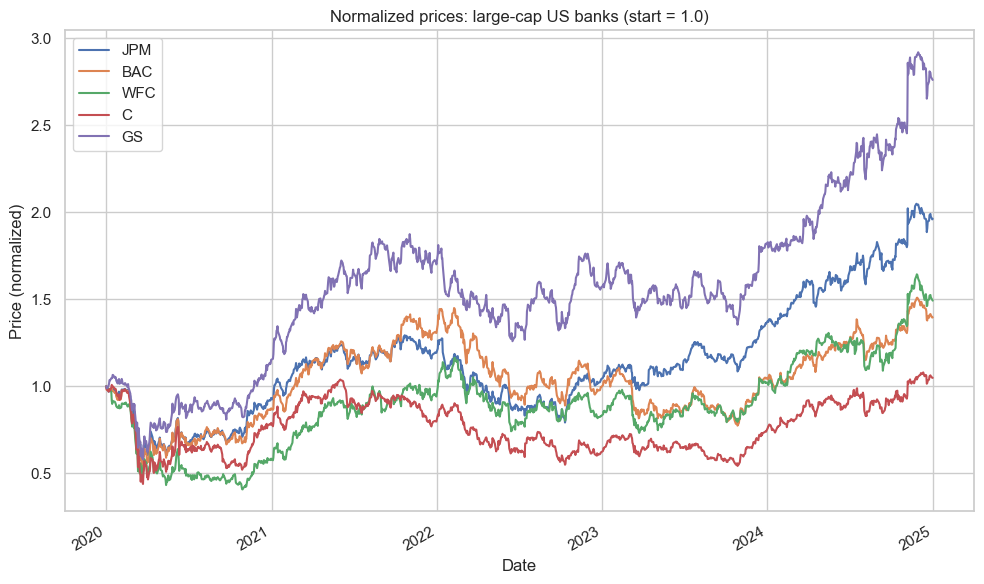

In [4]:
bank_tickers = ["JPM", "BAC", "WFC", "C", "GS"]
banks = prices[bank_tickers] / prices[bank_tickers].iloc[0]

ax = banks.plot(title="Normalized prices: large-cap US banks (start = 1.0)")
ax.set_ylabel("Price (normalized)")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

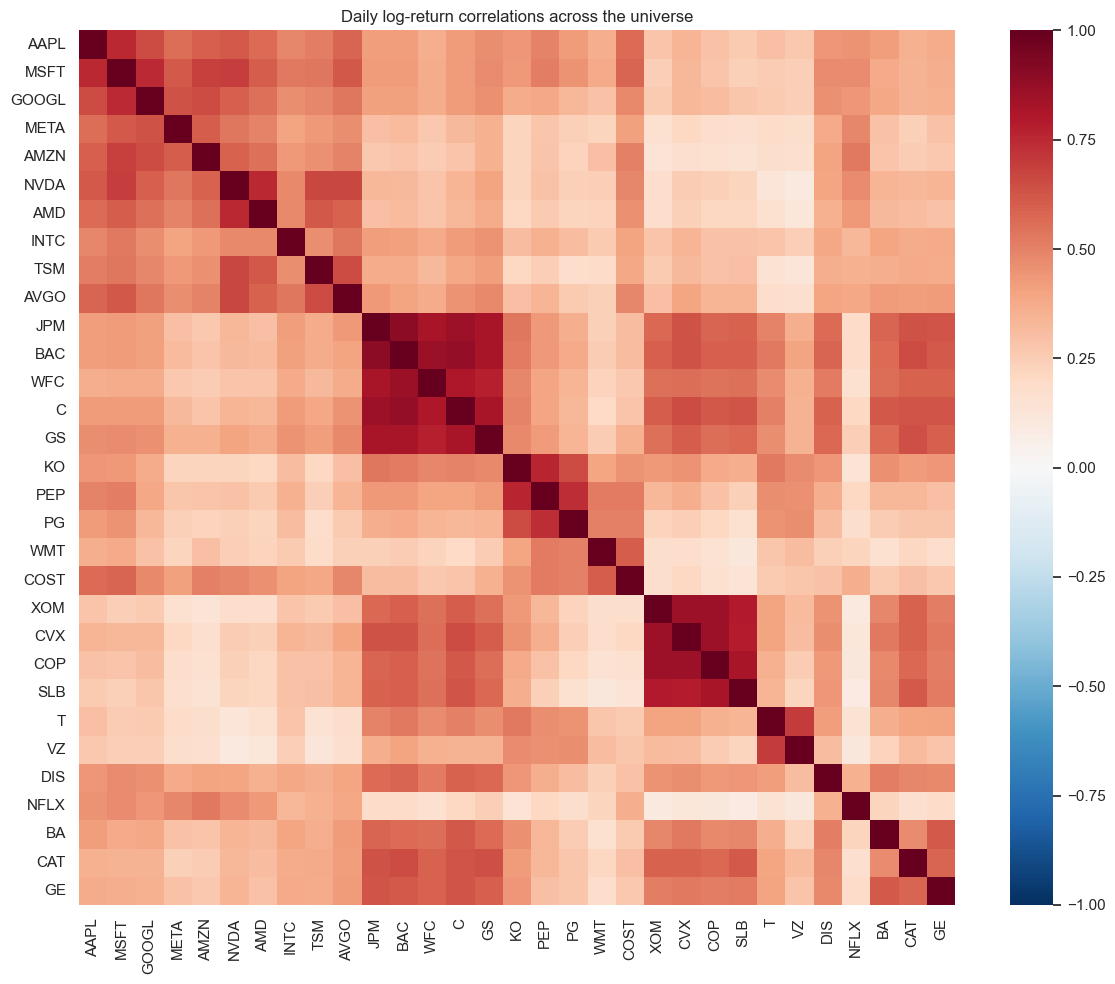

In [5]:
corr = returns.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=False)
plt.title("Daily log-return correlations across the universe")
plt.tight_layout()
plt.show()

In [6]:
# Get pairwise correlations as a long-format table, exclude self-pairs.
corr_long = corr.where(np.triu(np.ones_like(corr, dtype=bool), k=1)).stack()
corr_long = corr_long.sort_values(ascending=False)

# Top 20 most-correlated pairs.
print("Top 20 most-correlated pairs:")
print(corr_long.head(20))

Top 20 most-correlated pairs:
JPM   BAC      0.893854
BAC   C        0.875107
      WFC      0.863513
CVX   COP      0.858875
XOM   CVX      0.853373
JPM   C        0.852180
XOM   COP      0.852156
JPM   GS       0.827982
BAC   GS       0.826644
COP   SLB      0.824475
JPM   WFC      0.823048
C     GS       0.821482
WFC   C        0.812185
XOM   SLB      0.794131
CVX   SLB      0.784393
WFC   GS       0.774188
KO    PEP      0.758012
AAPL  MSFT     0.750913
NVDA  AMD      0.750715
MSFT  GOOGL    0.747925
dtype: float64
